# Sanity Check Raceline
This notebook visualizes the generated raceline on the map, including track boundaries, to ensure feasibility and safety margins.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
from PIL import Image
import os
import pandas as pd
import glob

In [27]:
MAP_NAME = "Map1_rc"
# MAP_NAME = "Spielberg_map"

In [28]:
if os.path.exists(f"maps/{MAP_NAME}.png"):
    map_img_path = f"maps/{MAP_NAME}.png"
elif os.path.exists(f"maps/{MAP_NAME}.pgm"):
    map_img_path = f"maps/{MAP_NAME}.pgm"
else:
    raise Exception("Map not found!")

map_yaml_path = f"maps/{MAP_NAME}.yaml"
map_img = np.array(Image.open(map_img_path).transpose(Image.FLIP_TOP_BOTTOM))
map_img = map_img.astype(np.float64)

# load map yaml
with open(map_yaml_path, 'r') as yaml_stream:
    try:
        map_metadata = yaml.safe_load(yaml_stream)
        map_resolution = map_metadata['resolution']
        origin = map_metadata['origin']
    except yaml.YAMLError as ex:
        print(ex)

# calculate map parameters
orig_x = origin[0]
orig_y = origin[1]
orig_s = np.sin(origin[2])
orig_c = np.cos(origin[2])


In [29]:
# load the latest raceline csv for this map
csv_files = glob.glob(f'outputs/{MAP_NAME}/*.csv')
if not csv_files:
    raise Exception("No raceline CSV files found in outputs directory!")
csv_files.sort(key=os.path.getmtime)
latest_csv = csv_files[-1]
print(f"Loading raceline from: {latest_csv}")

raw_data = pd.read_csv(latest_csv, comment='#')
# Ensure columns match expectations
if "x_m" not in raw_data.columns:
    # fallback if header is missing or different
    raw_data = pd.read_csv(latest_csv, header=None, skiprows=3)
    raw_data.columns = ['s_m', 'x_m', 'y_m', 'psi_rad', 'kappa_radpm', 'vx_mps', 'ax_mps2', 'w_tr_right_m', 'w_tr_left_m']

x = raw_data["x_m"].values.copy()
y = raw_data["y_m"].values.copy()
psi = raw_data["psi_rad"].values.copy()
wr = raw_data["w_tr_right_m"].values.copy()
wl = raw_data["w_tr_left_m"].values.copy()

# Calculate left and right boundary coordinates
x_left = x - wl * np.sin(psi)
y_left = y + wl * np.cos(psi)

x_right = x + wr * np.sin(psi)
y_right = y - wr * np.cos(psi)

# Transform real-world coordinates to map pixels
for arr in [x, x_left, x_right]:
    arr -= orig_x
    arr /= map_resolution
    
for arr in [y, y_left, y_right]:
    arr -= orig_y
    arr /= map_resolution


Loading raceline from: outputs/Map1_rc/Map1_rc_rl.csv


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


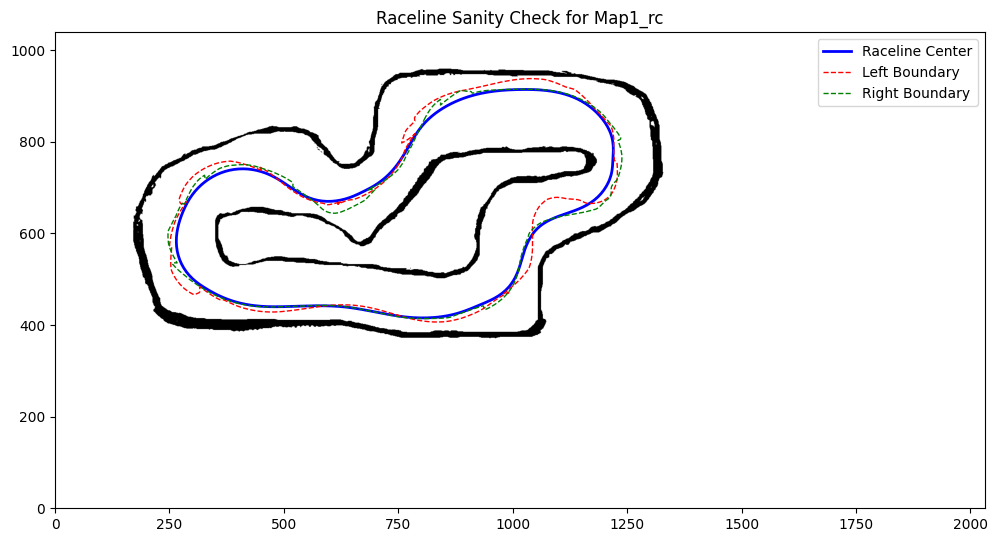

In [30]:
plt.figure(figsize=(12, 12))
plt.imshow(map_img, cmap="gray", origin="lower")
# Plot raceline
plt.plot(x, y, 'b-', label='Raceline Center', linewidth=2)
# Plot track boundaries based on raceline clearances
plt.plot(x_left, y_left, 'r--', label='Left Boundary', linewidth=1)
plt.plot(x_right, y_right, 'g--', label='Right Boundary', linewidth=1)

plt.legend()
plt.title(f"Raceline Sanity Check for {MAP_NAME}")
plt.show()
